# Dropout and Regularisation Trial

## Goal

Evaluate dropout and L2 regularisation settings while keeping the baseline architecture, activation, optimizer, learning rate, and batch size fixed.

## Setup

The configuration cell is the only cell normally edited in Colab.

In [ ]:
# Install only missing packages. Neural-network notebooks do not install or use
# TensorFlow, PyTorch, Keras, or scikit-learn neural-network implementations.
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}
missing = [pip_name for module, pip_name in required_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Environment ready.")

Environment ready.


In [ ]:
import copy
import hashlib
import json
import math
import os
import random
import time
import warnings
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy.signal import resample_poly

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

IN_COLAB = (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
)
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    default_root = Path("/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI")
else:
    default_root = Path.cwd()
    if not (default_root / "Fake Music Caps.zip").exists() and (default_root.parent / "Fake Music Caps.zip").exists():
        default_root = default_root.parent

# These environment variables provide a local-test override without changing
# the Colab defaults shown to a coursework reader.
PROJECT_ROOT = Path(os.environ.get("PROGMATHSAI_PROJECT_ROOT", str(default_root)))
ZIP_PATH = Path(os.environ.get("FAKEMUSICCAPS_ZIP_PATH", str(PROJECT_ROOT / "Datasets" / "Fake Music Caps.zip")))
DATA_DIR = Path(os.environ.get("FAKEMUSICCAPS_DATA_DIR", str(PROJECT_ROOT / "Datasets" / "Fake Music Caps")))
OUTPUT_ROOT = Path(os.environ.get("FAKEMUSICCAPS_OUTPUT_ROOT", str(PROJECT_ROOT / "task1_outputs")))

RUN_MODE = "final"
# Final submission mode is fixed intentionally.
# These notebooks always use the full configured split, full epoch/patience settings,
# and _final output files.

TRIAL_TAG = "03_dropout_regularisation_trial"
MODEL_TAG = "numpy_mlp_trials"
OUTPUT_DIR = OUTPUT_ROOT / MODEL_TAG / TRIAL_TAG
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_ROOT / MODEL_TAG / "cache"
for directory in (FIGURES_DIR, METRICS_DIR, MODELS_DIR, TABLES_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

FOLDER_TO_LABEL = {
    "audioldm2": 0,
    "MusicGen_medium": 1,
    "musicldm": 2,
    "mustango": 3,
    "stable_audio_open": 4,
}
CLASS_NAMES = ["AudioLDM2", "MusicGen", "MusicLDM", "Mustango", "Stable Audio Open"]

SAMPLE_RATE = 16_000
CLIP_SECONDS = 2.5
FRAME_MS = 25
HOP_MS = 10
N_FFT = 512
N_MELS = 26
N_MFCC = 20
POOL_FACTOR = 4

print({
    "run_mode": RUN_MODE,
    "trial_tag": TRIAL_TAG,
    "project_root": str(PROJECT_ROOT),
    "zip_path": str(ZIP_PATH),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
})

Mounted at /content/drive
{'run_mode': 'final', 'trial_tag': '03_dropout_regularisation_trial', 'project_root': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI', 'zip_path': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/Datasets/Fake Music Caps.zip', 'data_dir': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/Datasets/Fake Music Caps', 'output_dir': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/numpy_mlp_trials/03_dropout_regularisation_trial'}


## Data

Track IDs, rather than individual generated files, determine the split. Each split is balanced independently.

In [ ]:
def ensure_dataset_available():
    """Extract the archive only when the configured data directory is absent."""
    if DATA_DIR.exists():
        return DATA_DIR
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"Dataset folder not found at {DATA_DIR} and ZIP not found at {ZIP_PATH}. "
            "Update the configuration cell or upload the ZIP to Google Drive."
        )
    print(f"Extracting {ZIP_PATH.name}; this is a one-time operation...")
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR.parent)
    if not DATA_DIR.exists():
        raise FileNotFoundError(f"Archive extracted, but expected folder was not created: {DATA_DIR}")
    return DATA_DIR


def scan_dataset():
    root = ensure_dataset_available()
    missing_folders = [folder for folder in FOLDER_TO_LABEL if not (root / folder).is_dir()]
    if missing_folders:
        raise FileNotFoundError(f"Missing expected generator folders: {missing_folders}")

    rows = []
    for folder, label in FOLDER_TO_LABEL.items():
        paths = sorted((root / folder).glob("*.wav"))
        if not paths:
            raise ValueError(f"No WAV files found in {root / folder}")
        for path in paths:
            rows.append({
                "path": str(path),
                "track_id": path.stem,
                "folder": folder,
                "label": label,
                "class_name": CLASS_NAMES[label],
            })

    manifest = pd.DataFrame(rows)
    if manifest["path"].duplicated().any():
        raise AssertionError("Duplicate file paths found in the manifest.")
    valid_track_ids = manifest["track_id"].str.fullmatch(r"[A-Za-z0-9_-]{11}")
    if not valid_track_ids.all():
        invalid = manifest.loc[~valid_track_ids, "track_id"].drop_duplicates().head(10).tolist()
        raise ValueError(
            "Expected every WAV stem to be an 11-character track ID containing only "
            f"letters, digits, '_' or '-'. Invalid examples: {invalid}"
        )
    return manifest.sort_values(["track_id", "label"]).reset_index(drop=True)


def split_for_track_id(track_id, seed=RANDOM_SEED):
    # Stable across Python sessions, operating systems, and notebook order.
    digest = hashlib.sha256(f"{seed}:{track_id}".encode("utf-8")).hexdigest()
    bucket = int(digest[:8], 16) % 10_000
    if bucket < 7_000:
        return "train"
    if bucket < 8_500:
        return "validation"
    return "test"


def make_balanced_splits(manifest):
    selected_parts = []
    working = manifest.copy()
    working["split"] = working["track_id"].map(split_for_track_id)

    for split_index, split_name in enumerate(("train", "validation", "test")):
        split_df = working[working["split"] == split_name]
        counts = split_df.groupby("label").size().reindex(range(len(CLASS_NAMES)), fill_value=0)
        if (counts == 0).any():
            raise ValueError(f"At least one class is absent from {split_name}: {counts.to_dict()}")
        per_class = int(counts.min())
        for label in range(len(CLASS_NAMES)):
            class_rows = split_df[split_df["label"] == label]
            selected_parts.append(class_rows.sample(
                n=per_class,
                random_state=RANDOM_SEED + split_index * 100 + label,
                replace=False,
            ))

    selected = pd.concat(selected_parts, ignore_index=True)
    selected = selected.sort_values(["split", "label", "track_id"]).reset_index(drop=True)

    id_sets = {
        split: set(selected.loc[selected["split"] == split, "track_id"])
        for split in ("train", "validation", "test")
    }
    assert id_sets["train"].isdisjoint(id_sets["validation"])
    assert id_sets["train"].isdisjoint(id_sets["test"])
    assert id_sets["validation"].isdisjoint(id_sets["test"])
    return selected


def split_summary(selected):
    return (selected.groupby(["split", "class_name"])
            .size().rename("files").reset_index())

## NumPy MFCCs

Framing, FFT, mel filters, logarithms, and the DCT are implemented explicitly with NumPy.

In [ ]:
def load_wav_center_crop(path, target_sr=SAMPLE_RATE, seconds=CLIP_SECONDS):
    """Load, mono-convert, resample, and deterministically centre crop/pad a WAV."""
    sample_rate, audio = wavfile.read(path)
    if audio.ndim == 2:
        audio = audio.astype(np.float64).mean(axis=1)
    if np.issubdtype(audio.dtype, np.integer):
        scale = max(abs(np.iinfo(audio.dtype).min), np.iinfo(audio.dtype).max)
        audio = audio.astype(np.float64) / scale
    else:
        audio = audio.astype(np.float64)

    if sample_rate != target_sr:
        divisor = math.gcd(int(sample_rate), int(target_sr))
        audio = resample_poly(audio, target_sr // divisor, sample_rate // divisor)

    target_length = int(round(target_sr * seconds))
    if len(audio) >= target_length:
        start = (len(audio) - target_length) // 2
        audio = audio[start:start + target_length]
    else:
        left = (target_length - len(audio)) // 2
        right = target_length - len(audio) - left
        audio = np.pad(audio, (left, right))

    peak = np.max(np.abs(audio)) if audio.size else 0.0
    if peak > 1.0:
        audio = audio / peak
    return audio.astype(np.float32)


def hz_to_mel(frequency_hz):
    return 2595.0 * np.log10(1.0 + np.asarray(frequency_hz) / 700.0)


def mel_to_hz(mel_value):
    return 700.0 * (10.0 ** (np.asarray(mel_value) / 2595.0) - 1.0)


def mel_filter_bank(sample_rate=SAMPLE_RATE, n_fft=N_FFT, n_mels=N_MELS):
    mel_points = np.linspace(hz_to_mel(0), hz_to_mel(sample_rate / 2), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    bins = np.clip(bins, 0, n_fft // 2)

    filters = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float64)
    for index in range(1, n_mels + 1):
        left, centre, right = bins[index - 1:index + 2]
        centre = max(centre, left + 1)
        right = max(right, centre + 1)
        for frequency_bin in range(left, min(centre, filters.shape[1])):
            filters[index - 1, frequency_bin] = (frequency_bin - left) / (centre - left)
        for frequency_bin in range(centre, min(right, filters.shape[1])):
            filters[index - 1, frequency_bin] = (right - frequency_bin) / (right - centre)
    return filters


def dct_basis(n_mfcc=N_MFCC, n_mels=N_MELS):
    mel_indices = np.arange(n_mels)
    coefficient_indices = np.arange(n_mfcc)[:, None]
    basis = np.cos(np.pi * coefficient_indices * (2 * mel_indices + 1) / (2 * n_mels))
    basis *= np.sqrt(2.0 / n_mels)
    basis[0] /= np.sqrt(2.0)
    return basis


MEL_FILTERS = mel_filter_bank()
DCT_BASIS = dct_basis()


def numpy_mfcc(audio):
    """Return frames x coefficients MFCCs using NumPy for the feature mathematics."""
    if audio.ndim != 1:
        raise ValueError("numpy_mfcc expects mono one-dimensional audio.")
    emphasized = np.empty_like(audio, dtype=np.float64)
    emphasized[0] = audio[0]
    emphasized[1:] = audio[1:] - 0.97 * audio[:-1]

    frame_length = int(round(SAMPLE_RATE * FRAME_MS / 1000))
    hop_length = int(round(SAMPLE_RATE * HOP_MS / 1000))
    frame_count = 1 + int(np.ceil(max(0, len(emphasized) - frame_length) / hop_length))
    padded_length = (frame_count - 1) * hop_length + frame_length
    padded = np.pad(emphasized, (0, max(0, padded_length - len(emphasized))))
    indices = (np.arange(frame_length)[None, :] +
               hop_length * np.arange(frame_count)[:, None])
    frames = padded[indices] * np.hamming(frame_length)

    spectrum = np.fft.rfft(frames, n=N_FFT, axis=1)
    power = (np.abs(spectrum) ** 2) / N_FFT
    mel_energy = np.maximum(power @ MEL_FILTERS.T, 1e-12)
    log_mel = np.log(mel_energy)
    mfcc = log_mel @ DCT_BASIS.T
    if not np.isfinite(mfcc).all():
        raise FloatingPointError("Non-finite MFCC value encountered.")
    return mfcc.astype(np.float32)


def pool_mfcc_time(mfcc, factor=POOL_FACTOR):
    usable = (len(mfcc) // factor) * factor
    if usable == 0:
        raise ValueError("MFCC sequence is too short to pool.")
    return mfcc[:usable].reshape(-1, factor, mfcc.shape[1]).mean(axis=1)


def aggregate_mfcc(mfcc):
    delta = np.gradient(mfcc.astype(np.float64), axis=0)
    vector = np.concatenate([
        mfcc.mean(axis=0), mfcc.std(axis=0),
        delta.mean(axis=0), delta.std(axis=0),
    ])
    if vector.shape != (80,):
        raise AssertionError(f"Expected 80 aggregated features, got {vector.shape}")
    return vector.astype(np.float32)


def extract_representation(path, representation):
    audio = load_wav_center_crop(path)
    mfcc = numpy_mfcc(audio)
    if representation == "aggregated":
        return aggregate_mfcc(mfcc)
    pooled = pool_mfcc_time(mfcc)
    if representation == "sequence":
        return pooled.astype(np.float32)
    if representation == "map":
        return pooled.T[None, :, :].astype(np.float32)  # channel x coefficients x time
    raise ValueError(f"Unknown representation: {representation}")

In [ ]:
def feature_fingerprint(representation):
    parameters = {
        "sample_rate": SAMPLE_RATE,
        "clip_seconds": CLIP_SECONDS,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "n_fft": N_FFT,
        "n_mels": N_MELS,
        "n_mfcc": N_MFCC,
        "pool_factor": POOL_FACTOR,
        "representation": representation,
    }
    return hashlib.sha256(json.dumps(parameters, sort_keys=True).encode()).hexdigest()[:12]


def build_or_load_split_features(selected, split_name, representation):
    subset = selected[selected["split"] == split_name].reset_index(drop=True)
    fingerprint = feature_fingerprint(representation)
    cache_path = CACHE_DIR / f"{MODEL_TAG}_{RUN_MODE}_{split_name}_{representation}_{fingerprint}.npz"
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        X = cached["X"]
        y = cached["y"]
        paths = cached["paths"].astype(str)
        if len(X) != len(subset) or not np.array_equal(y, subset["label"].to_numpy()):
            raise ValueError(f"Cache does not match the current manifest: {cache_path}")
        if not np.isfinite(X).all():
            raise FloatingPointError(f"Cache contains non-finite values: {cache_path}")
        print(f"Loaded {split_name} {representation} cache: {X.shape}")
        return X, y, paths

    features = []
    failures = []
    for row in subset.itertuples(index=False):
        try:
            features.append(extract_representation(row.path, representation))
        except Exception as exc:
            failures.append((row.path, repr(exc)))
    if failures:
        preview = "\n".join(f"- {path}: {error}" for path, error in failures[:10])
        raise RuntimeError(f"Feature extraction failed for {len(failures)} files:\n{preview}")

    X = np.stack(features).astype(np.float32)
    y = subset["label"].to_numpy(dtype=np.int64)
    paths = subset["path"].astype(str).to_numpy(dtype=str)
    if not np.isfinite(X).all():
        raise FloatingPointError("Feature extraction produced non-finite values.")
    np.savez_compressed(cache_path, X=X, y=y, paths=paths)
    print(f"Saved {split_name} {representation} cache: {X.shape}")
    return X, y, paths
def prepare_validation_features(representation):
    """Prepare train and validation features only for hyperparameter trials.

    The held-out test audio is deliberately not featurised in trial notebooks.
    Test evaluation is reserved for 07_MLP_Final_Selected_Model.ipynb.
    """
    manifest = scan_dataset()
    selected = make_balanced_splits(manifest)
    print(split_summary(selected).to_string(index=False))
    data = {
        "train": build_or_load_split_features(selected, "train", representation),
        "validation": build_or_load_split_features(selected, "validation", representation),
    }
    return manifest, selected, data


def standardize_train_validation_features(X_train, X_validation, representation):
    if representation == "aggregated":
        axes = (0,)
    elif representation == "sequence":
        axes = (0, 1)
    elif representation == "map":
        axes = (0, 1, 3)  # one mean/std per MFCC coefficient
    else:
        raise ValueError(representation)
    mean = X_train.mean(axis=axes, keepdims=True)
    std = X_train.std(axis=axes, keepdims=True) + 1e-6
    return (
        ((X_train - mean) / std).astype(np.float32),
        ((X_validation - mean) / std).astype(np.float32),
        mean.astype(np.float32),
        std.astype(np.float32),
    )

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)


def classification_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(CLASS_NAMES)),
        average="macro", zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }


def plot_confusion(y_true, y_pred, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
    row_sums = np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    normalized = matrix / row_sums
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    for row in range(len(CLASS_NAMES)):
        for column in range(len(CLASS_NAMES)):
            ax.text(column, row, f"{matrix[row, column]}\n{normalized[row, column]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if normalized[row, column] > 0.55 else "black")
    ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=35, ha="right")
    ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    ax.set_xlabel("Predicted generator")
    ax.set_ylabel("True generator")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Row-normalized proportion")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return matrix


def save_json(payload, path):
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved {path}")


def save_prediction_table(paths, y_true, y_pred, output_path):
    table = pd.DataFrame({
        "path": paths,
        "true_label": y_true,
        "true_class": [CLASS_NAMES[index] for index in y_true],
        "predicted_label": y_pred,
        "predicted_class": [CLASS_NAMES[index] for index in y_pred],
    })
    table.to_csv(output_path, index=False)
    return table

## Steps

The assessed fully connected model implements every layer and optimizer directly with NumPy.

In [ ]:
manifest, selected, data = prepare_validation_features("aggregated")
X_train, y_train, train_paths = data["train"]
X_validation, y_validation, validation_paths = data["validation"]
X_train, X_validation, feature_mean, feature_std = standardize_train_validation_features(
    X_train, X_validation, "aggregated"
)
assert X_train.shape[1] == 80
assert set(y_train) == set(range(len(CLASS_NAMES)))
print("Prepared validation-trial shapes:", X_train.shape, X_validation.shape)

     split        class_name  files
      test         AudioLDM2    197
      test          MusicGen    197
      test          MusicLDM    197
      test          Mustango    197
      test Stable Audio Open    197
     train         AudioLDM2    864
     train          MusicGen    864
     train          MusicLDM    864
     train          Mustango    864
     train Stable Audio Open    864
validation         AudioLDM2    196
validation          MusicGen    196
validation          MusicLDM    196
validation          Mustango    196
validation Stable Audio Open    196
Loaded train aggregated cache: (4320, 80)
Loaded validation aggregated cache: (980, 80)
Prepared validation-trial shapes: (4320, 80) (980, 80)


In [ ]:
def stable_softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


def softmax_backward(upstream, probabilities):
    # Vector-Jacobian product for a standalone softmax layer.
    return probabilities * (upstream - np.sum(upstream * probabilities, axis=1, keepdims=True))


def cross_entropy(probabilities, labels):
    return float(-np.log(np.clip(probabilities[np.arange(len(labels)), labels], 1e-12, 1.0)).mean())


class Dense:
    def __init__(self, input_size, output_size, rng, initialization="he"):
        scale = np.sqrt(2.0 / input_size) if initialization == "he" else np.sqrt(1.0 / input_size)
        self.W = (rng.standard_normal((input_size, output_size)) * scale).astype(np.float64)
        self.b = np.zeros(output_size, dtype=np.float64)

    def forward(self, inputs):
        self.inputs = inputs
        return inputs @ self.W + self.b

    def backward(self, upstream):
        self.dW = self.inputs.T @ upstream
        self.db = upstream.sum(axis=0)
        return upstream @ self.W.T


class ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        return np.maximum(inputs, 0.0)

    def backward(self, upstream):
        return upstream * (self.inputs > 0)


class Sigmoid:
    def forward(self, inputs):
        self.output = np.empty_like(inputs, dtype=np.float64)
        positive = inputs >= 0
        self.output[positive] = 1.0 / (1.0 + np.exp(-inputs[positive]))
        exp_values = np.exp(inputs[~positive])
        self.output[~positive] = exp_values / (1.0 + exp_values)
        return self.output

    def backward(self, upstream):
        return upstream * self.output * (1.0 - self.output)


class Dropout:
    def __init__(self, probability, rng):
        if not 0.0 <= probability < 1.0:
            raise ValueError("Dropout probability must be in [0, 1).")
        self.probability = probability
        self.rng = rng

    def forward(self, inputs, training, fixed_mask=None):
        if not training or self.probability == 0.0:
            self.mask = np.ones_like(inputs)
        elif fixed_mask is not None:
            self.mask = fixed_mask
        else:
            keep = self.rng.random(inputs.shape) >= self.probability
            self.mask = keep / (1.0 - self.probability)
        return inputs * self.mask

    def backward(self, upstream):
        return upstream * self.mask


class SGDOptimizer:
    def __init__(self, learning_rate=0.01, decay=0.0):
        self.learning_rate = learning_rate
        self.decay = decay

    def step(self, layers, epoch):
        rate = self.learning_rate / (1.0 + self.decay * epoch)
        for layer in layers:
            layer.W -= rate * layer.dW
            layer.b -= rate * layer.db
        return rate


class MomentumOptimizer:
    def __init__(self, learning_rate=0.01, momentum=0.9, decay=0.0):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.decay = decay
        self.velocity = {}

    def step(self, layers, epoch):
        rate = self.learning_rate / (1.0 + self.decay * epoch)
        for layer in layers:
            key = id(layer)
            if key not in self.velocity:
                self.velocity[key] = [np.zeros_like(layer.W), np.zeros_like(layer.b)]
            velocity_w, velocity_b = self.velocity[key]
            velocity_w[:] = self.momentum * velocity_w - rate * layer.dW
            velocity_b[:] = self.momentum * velocity_b - rate * layer.db
            layer.W += velocity_w
            layer.b += velocity_b
        return rate


class NumPyMLP:
    def __init__(self, input_size, hidden_sizes, hidden_activation, dropout_rate,
                 l1=0.0, l2=0.0, seed=RANDOM_SEED):
        self.rng = np.random.default_rng(seed)
        self.l1, self.l2 = l1, l2
        sizes = [input_size, *hidden_sizes, len(CLASS_NAMES)]
        self.dense_layers = []
        self.activations = []
        self.dropouts = []
        for index in range(len(sizes) - 1):
            initialization = "xavier" if hidden_activation == "sigmoid" else "he"
            self.dense_layers.append(Dense(sizes[index], sizes[index + 1], self.rng, initialization))
            if index < len(sizes) - 2:
                self.activations.append(ReLU() if hidden_activation == "relu" else Sigmoid())
                self.dropouts.append(Dropout(dropout_rate, self.rng))

    def forward(self, inputs, training=False):
        output = inputs.astype(np.float64)
        for dense, activation, dropout in zip(self.dense_layers[:-1], self.activations, self.dropouts):
            output = dropout.forward(activation.forward(dense.forward(output)), training=training)
        return stable_softmax(self.dense_layers[-1].forward(output))

    def loss(self, probabilities, labels):
        penalty = 0.0
        for layer in self.dense_layers:
            penalty += self.l1 * np.abs(layer.W).sum() + 0.5 * self.l2 * np.square(layer.W).sum()
        return cross_entropy(probabilities, labels) + penalty / len(labels)

    def backward(self, probabilities, labels):
        gradient = probabilities.copy()
        gradient[np.arange(len(labels)), labels] -= 1.0
        gradient /= len(labels)
        gradient = self.dense_layers[-1].backward(gradient)
        for index in reversed(range(len(self.activations))):
            gradient = self.dropouts[index].backward(gradient)
            gradient = self.activations[index].backward(gradient)
            gradient = self.dense_layers[index].backward(gradient)
        for layer in self.dense_layers:
            layer.dW += self.l1 * np.sign(layer.W) / len(labels) + self.l2 * layer.W / len(labels)

    def predict(self, inputs):
        return self.forward(inputs, training=False).argmax(axis=1)

    def state_dict(self):
        return [(layer.W.copy(), layer.b.copy()) for layer in self.dense_layers]

    def load_state_dict(self, state):
        for layer, (weights, bias) in zip(self.dense_layers, state):
            layer.W[:] = weights
            layer.b[:] = bias

    def parameter_count(self):
        return int(sum(layer.W.size + layer.b.size for layer in self.dense_layers))

### Gradient checks

Finite differences verify dense, sigmoid, ReLU, softmax, and fixed-mask dropout derivatives.

In [ ]:
def finite_difference(array, index, objective, epsilon=1e-5):
    original = array[index]
    array[index] = original + epsilon
    plus = objective()
    array[index] = original - epsilon
    minus = objective()
    array[index] = original
    return (plus - minus) / (2 * epsilon)


def relative_error(analytical, numerical):
    return abs(analytical - numerical) / max(1e-8, abs(analytical) + abs(numerical))


rng = np.random.default_rng(7)
check_x = rng.normal(size=(3, 4))
check_labels = np.array([0, 1, 2])
check_model = NumPyMLP(4, [5], "sigmoid", 0.0, seed=8)
check_probabilities = check_model.forward(check_x, training=True)
check_model.backward(check_probabilities, check_labels)

def check_objective():
    return cross_entropy(check_model.forward(check_x, training=False), check_labels)

checks = []
for index in [(0, 0), (2, 3), (3, 4)]:
    numerical = finite_difference(check_model.dense_layers[0].W, index, check_objective)
    analytical = check_model.dense_layers[0].dW[index]
    checks.append(relative_error(analytical, numerical))

# Standalone sigmoid and ReLU checks keep activation derivatives explicit.
sigmoid = Sigmoid()
sigmoid_input = np.array([[-1.2, 0.4], [1.1, -0.7]], dtype=float)
sigmoid_upstream = rng.normal(size=sigmoid_input.shape)
sigmoid.forward(sigmoid_input)
sigmoid_gradient = sigmoid.backward(sigmoid_upstream)
def sigmoid_objective():
    return float(np.sum(sigmoid.forward(sigmoid_input) * sigmoid_upstream))
sigmoid_numeric = finite_difference(sigmoid_input, (0, 1), sigmoid_objective)
checks.append(relative_error(sigmoid_gradient[0, 1], sigmoid_numeric))

relu = ReLU()
relu_input = np.array([[-1.3, 0.7], [2.1, -0.9]], dtype=float)
relu_upstream = rng.normal(size=relu_input.shape)
relu.forward(relu_input)
relu_gradient = relu.backward(relu_upstream)
def relu_objective():
    return float(np.sum(relu.forward(relu_input) * relu_upstream))
relu_numeric = finite_difference(relu_input, (1, 0), relu_objective)
checks.append(relative_error(relu_gradient[1, 0], relu_numeric))

# Standalone softmax vector-Jacobian check.
logits = rng.normal(size=(2, 5))
upstream = rng.normal(size=(2, 5))
probabilities = stable_softmax(logits)
softmax_gradient = softmax_backward(upstream, probabilities)
def softmax_objective():
    return float(np.sum(stable_softmax(logits) * upstream))
softmax_numeric = finite_difference(logits, (0, 2), softmax_objective)
checks.append(relative_error(softmax_gradient[0, 2], softmax_numeric))

# Fixed-mask inverted-dropout gradient check.
dropout = Dropout(0.5, rng)
dropout_input = rng.normal(size=(2, 3))
dropout_upstream = rng.normal(size=(2, 3))
fixed_mask = np.array([[2, 0, 2], [0, 2, 0]], dtype=float)
dropout.forward(dropout_input, training=True, fixed_mask=fixed_mask)
dropout_gradient = dropout.backward(dropout_upstream)
def dropout_objective():
    return float(np.sum(dropout_input * fixed_mask * dropout_upstream))
dropout_numeric = finite_difference(dropout_input, (0, 2), dropout_objective)
checks.append(relative_error(dropout_gradient[0, 2], dropout_numeric))

print("Maximum MLP component gradient-check error:", max(checks))
assert max(checks) < 1e-5

Maximum MLP component gradient-check error: 3.416854045622885e-10


### Dropout and weight regularisation experiment

This notebook changes one main modelling factor and saves validation outputs only. The held-out test split is reserved for the final selected-model notebook.

Training no_regularisation
Training dropout_0p2
Training dropout_0p3
Training l2_1e_minus_4
Training dropout_0p2_l2_1e_minus_4


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,trial,trial_factor,variant,epochs_trained,parameter_count,hidden_sizes_json,activation,dropout,l1,l2,optimizer,learning_rate,decay,batch_size,configured_epochs
0,0.727551,0.727551,0.727197,0.727551,0.727080,03_dropout_regularisation_trial,Dropout and weight regularisation,dropout_0p2_l2_1e_minus_4,37,18949,"[128, 64]",relu,0.2,0.0,0.0001,momentum,0.01,0.01,64,50
1,0.717347,0.717347,0.717771,0.717347,0.717482,03_dropout_regularisation_trial,Dropout and weight regularisation,dropout_0p2,35,18949,"[128, 64]",relu,0.2,0.0,0.0000,momentum,0.01,0.01,64,50
2,0.715306,0.715306,0.715196,0.715306,0.713778,03_dropout_regularisation_trial,Dropout and weight regularisation,dropout_0p3,48,18949,"[128, 64]",relu,0.3,0.0,0.0000,momentum,0.01,0.01,64,50
3,0.685714,0.685714,0.690364,0.685714,0.687315,03_dropout_regularisation_trial,Dropout and weight regularisation,l2_1e_minus_4,14,18949,"[128, 64]",relu,0.0,0.0,0.0001,momentum,0.01,0.01,64,50
4,0.684694,0.684694,0.689366,0.684694,0.686374,03_dropout_regularisation_trial,Dropout and weight regularisation,no_regularisation,14,18949,"[128, 64]",relu,0.0,0.0,0.0000,momentum,0.01,0.01,64,50


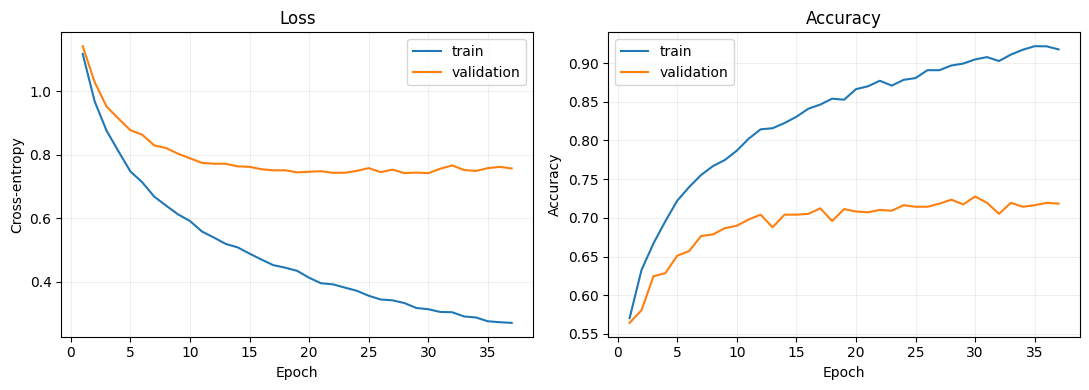

Saved /content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/numpy_mlp_trials/03_dropout_regularisation_trial/metrics/trial_summary_03_dropout_regularisation_trial_final.json
Saved validation outputs to /content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/numpy_mlp_trials/03_dropout_regularisation_trial


In [ ]:
def iterate_minibatches(X, y, batch_size, rng):
    order = rng.permutation(len(X))
    for start in range(0, len(X), batch_size):
        batch = order[start:start + batch_size]
        yield X[batch], y[batch]


def train_mlp(configuration):
    model = NumPyMLP(
        X_train.shape[1], configuration["hidden_sizes"], configuration["activation"],
        configuration["dropout"], configuration.get("l1", 0.0), configuration.get("l2", 0.0),
        seed=RANDOM_SEED,
    )
    if configuration["optimizer"] == "sgd":
        optimizer = SGDOptimizer(configuration["learning_rate"], configuration["decay"])
    else:
        optimizer = MomentumOptimizer(configuration["learning_rate"], 0.9, configuration["decay"])

    epochs = configuration.get("epochs", 50)
    patience = configuration.get("patience", 7)
    batch_size = min(configuration.get("batch_size", 64), len(X_train))
    rng = np.random.default_rng(RANDOM_SEED)
    history = []
    best_loss = np.inf
    best_state = None
    stale_epochs = 0

    for epoch in range(epochs):
        for batch_X, batch_y in iterate_minibatches(X_train, y_train, batch_size, rng):
            probabilities = model.forward(batch_X, training=True)
            model.backward(probabilities, batch_y)
            learning_rate = optimizer.step(model.dense_layers, epoch)

        train_probabilities = model.forward(X_train, training=False)
        validation_probabilities = model.forward(X_validation, training=False)
        row = {
            "epoch": epoch + 1,
            "learning_rate": learning_rate,
            "train_loss": model.loss(train_probabilities, y_train),
            "validation_loss": model.loss(validation_probabilities, y_validation),
            "train_accuracy": float((train_probabilities.argmax(1) == y_train).mean()),
            "validation_accuracy": float((validation_probabilities.argmax(1) == y_validation).mean()),
        }
        history.append(row)
        if row["validation_loss"] < best_loss - 1e-6:
            best_loss = row["validation_loss"]
            best_state = model.state_dict()
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break

    if best_state is None:
        best_state = model.state_dict()
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def to_jsonable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {key: to_jsonable(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_jsonable(item) for item in value]
    return value


trial_configs = [{'name': 'no_regularisation',
  'hidden_sizes': [128, 64],
  'activation': 'relu',
  'dropout': 0.0,
  'l1': 0.0,
  'l2': 0.0,
  'optimizer': 'momentum',
  'learning_rate': 0.01,
  'decay': 0.01,
  'batch_size': 64,
  'epochs': 50},
 {'name': 'dropout_0p2',
  'hidden_sizes': [128, 64],
  'activation': 'relu',
  'dropout': 0.2,
  'l1': 0.0,
  'l2': 0.0,
  'optimizer': 'momentum',
  'learning_rate': 0.01,
  'decay': 0.01,
  'batch_size': 64,
  'epochs': 50},
 {'name': 'dropout_0p3',
  'hidden_sizes': [128, 64],
  'activation': 'relu',
  'dropout': 0.3,
  'l1': 0.0,
  'l2': 0.0,
  'optimizer': 'momentum',
  'learning_rate': 0.01,
  'decay': 0.01,
  'batch_size': 64,
  'epochs': 50},
 {'name': 'l2_1e_minus_4',
  'hidden_sizes': [128, 64],
  'activation': 'relu',
  'dropout': 0.0,
  'l1': 0.0,
  'l2': 0.0001,
  'optimizer': 'momentum',
  'learning_rate': 0.01,
  'decay': 0.01,
  'batch_size': 64,
  'epochs': 50},
 {'name': 'dropout_0p2_l2_1e_minus_4',
  'hidden_sizes': [128, 64],
  'activation': 'relu',
  'dropout': 0.2,
  'l1': 0.0,
  'l2': 0.0001,
  'optimizer': 'momentum',
  'learning_rate': 0.01,
  'decay': 0.01,
  'batch_size': 64,
  'epochs': 50}]

validation_rows, histories = [], {}
training_start = time.perf_counter()
for configuration in trial_configs:
    print(f"Training {configuration['name']}")
    model, history = train_mlp(configuration)
    prediction = model.predict(X_validation)
    row = classification_metrics(y_validation, prediction)
    row.update({
        "trial": TRIAL_TAG,
        "trial_factor": "Dropout and weight regularisation",
        "variant": configuration["name"],
        "epochs_trained": int(len(history)),
        "parameter_count": model.parameter_count(),
        "hidden_sizes_json": json.dumps(configuration["hidden_sizes"]),
        "activation": configuration["activation"],
        "dropout": float(configuration.get("dropout", 0.0)),
        "l1": float(configuration.get("l1", 0.0)),
        "l2": float(configuration.get("l2", 0.0)),
        "optimizer": configuration["optimizer"],
        "learning_rate": float(configuration["learning_rate"]),
        "decay": float(configuration.get("decay", 0.0)),
        "batch_size": int(configuration.get("batch_size", 64)),
        "configured_epochs": int(configuration.get("epochs", 50)),
    })
    validation_rows.append(row)
    histories[configuration["name"]] = history

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["macro_f1", "balanced_accuracy", "accuracy"], ascending=False
).reset_index(drop=True)
display(validation_results)

best_variant = validation_results.iloc[0]["variant"]
best_history = histories[best_variant]
validation_path = TABLES_DIR / f"validation_{TRIAL_TAG}_{RUN_MODE}.csv"
history_path = TABLES_DIR / f"training_history_{TRIAL_TAG}_{RUN_MODE}.csv"
summary_path = METRICS_DIR / f"trial_summary_{TRIAL_TAG}_{RUN_MODE}.json"
validation_results.to_csv(validation_path, index=False)
best_history.to_csv(history_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(best_history["epoch"], best_history["train_loss"], label="train")
axes[0].plot(best_history["epoch"], best_history["validation_loss"], label="validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[1].plot(best_history["epoch"], best_history["train_accuracy"], label="train")
axes[1].plot(best_history["epoch"], best_history["validation_accuracy"], label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.grid(alpha=0.2)
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"training_curves_{TRIAL_TAG}_{RUN_MODE}.png", dpi=160)
plt.show()

payload = {
    "model": "NumPy MLP",
    "trial": TRIAL_TAG,
    "trial_factor": "Dropout and weight regularisation",
    "run_mode": RUN_MODE,
    "selection_metric": "validation_macro_f1_then_balanced_accuracy_then_accuracy",
    "selection_scope": "validation_only",
    "test_evaluation": "not_performed_in_this_notebook",
    "best_variant": best_variant,
    "best_validation": validation_results.iloc[0].to_dict(),
    "configs": trial_configs,
    "runtime_seconds": float(time.perf_counter() - training_start),
    "validation_table": str(validation_path),
    "best_history_table": str(history_path),
}
save_json(to_jsonable(payload), summary_path)
print(f"Saved validation outputs to {OUTPUT_DIR}")
